<a href="https://colab.research.google.com/github/M-Hagemann87/aviation_risk_estimation/blob/main/aviation_risk_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Multi-Task NLP for Aviation Incident Risk Estimation

## Table of Contents:


1. Business Problem
2. Data Audit
3. NLP Feature Engineering
4. Multi-Task Modeling Strategy
5. Risk Estimation Layer
6. Deployment
7. Final Conclusions
---

---
# **1.	Business Problem**

### ✔ Dataset:
- The dataset contains approximately 38,000 aviation safety incident reports from NASA's Aviation Safety Reporting System (ASRS), covering the period from January 2012 to March 2022. The data includes both structured metadata and unstructured narrative descriptions and was accessed via Hugging Face.

### ✔ Objective:
- Develop a multi-task NLP system that extracts structured incident attributes from unstructured safety narratives and integrates them into an ICAO-inspired risk estimation framework, deployed as a Hugging Face Spaces application for interactive risk assessment.

**Note:** Although the ICAO risk matrix can be applied to multiple risk domains (people, property, economic impact, reputation, and operational capability), this project focuses exclusively on personal safety.

### ✔ Target Variable:
- This project uses a multi-task transformer model to simultaneously predict three structured incident attributes:
   * `Primary_Problem` (formerly Assessments.1_Primary Problem).
   * `Events_Anomaly`.
   * `Events_Result` (formerly Events.5_Result).
- These variables are used exclusively as supervised training labels and are not available as input features during inference, preventing information leakage.

### ✔ Modeling Approach:
- A pretrained DistilBERT transformer is fine-tuned using a multi-head classification architecture, where a shared encoder feeds three independent classification heads corresponding to each target variable.

### ✔ Evaluation Metric
- Primary: Macro F1-score (weights all classes equally regardless of support, exposing performance on minority classes under severe class imbalance).
- Secondary: Accuracy and confusion matrix for error analysis.

### ✔ Validation Strategy
- A 70/15/15 stratified train/validation/test split based on the primary target variable is used to preserve class distribution across partitions.

### ✔ Risk Estimation Philosophy
- Machine learning predicts structured incident attributes. A deterministic risk estimation layer then maps these predictions into severity and probability levels using predefined engineering weights aligned with the ICAO 5×5 risk matrix. This separation ensures interpretability and prevents circular training on engineered risk scores.

---
# **2. Data Audit**

\- This section performs an initial audit on the dataset, including schema inspection, missing-value analysis, and identification of candidate features for modeling.


### → Action:

- Import core libraries for data analysis and visualization.
- Additional specialized libraries are imported throughout the project.

In [ ]:
## Core libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Pip installation
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


- Mount Google Drive to access files.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### → Action:
- Download the dataset and convert it to a pandas DataFrame.
- A copy of the DataFrame `df_original` was created to preserve the raw data. All subsequent preprocessing and analysis are performed on the working DataFrame `df`.

In [ ]:
## Import dataset and convert to dataframe
# Hugging face dataset
from datasets import load_dataset

# Load ASRS aviation incident reports from the Hugging Face Hub
ds = load_dataset("elihoole/asrs-aviation-reports")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

asrs-aviation-reports-train.jsonl:   0%|          | 0.00/270M [00:00<?, ?B/s]

asrs-aviation-reports-validation.jsonl:   0%|          | 0.00/29.9M [00:00<?, ?B/s]

asrs-aviation-reports-test.jsonl:   0%|          | 0.00/33.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/38655 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4295 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4773 [00:00<?, ? examples/s]

In [ ]:
# Load the DataSet into pandas Dataframe
df_original = ds["train"].to_pandas()

# Create a working copy while preserving the raw dataset
df = df_original.copy()

### → Action:

- Initial exploration on the dataframe.

In [ ]:
print(df.shape)
df.info()

(38655, 111)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38655 entries, 0 to 38654
Columns: 111 entries, acn_num_ACN to Report 1.2_Synopsis
dtypes: object(111)
memory usage: 32.7+ MB


### → Action:
- Inspect the rows and columns from the dataframe to overview the data.
- Check for the time coverage.

In [ ]:
df.head(3)


,acn_num_ACN,Time_Date,Time.1_Local Time Of Day,Place_Locale Reference,Place.1_State Reference,Place.2_Relative Position.Angle.Radial,Place.3_Relative Position.Distance.Nautical Miles,Place.4_Altitude.AGL.Single Value,Place.5_Altitude.MSL.Single Value,Environment_Flight Conditions,...,Events.3_Detector,Events.4_When Detected,Events.5_Result,Assessments_Contributing Factors / Situations,Assessments.1_Primary Problem,Report 1_Narrative,Report 1.1_Callback,Report 2_Narrative,Report 2.1_Callback,Report 1.2_Synopsis
0,1574675,201808,0601-1200,SNA.Airport,CA,,,,5000.0,,...,Person Air Traffic Control; Person Flight Crew,In-flight,Air Traffic Control Issued New Clearance; Flig...,Human Factors,Human Factors,SNA RNP-Z to Runway 20R. The FMC was properly ...,,We were cleared for the RNP RNAV Z 20R Approac...,,B737-700 flight crew reported failing to make ...
1,1224894,201412,0601-1200,MSY.Airport,LA,,,1000.0,,VMC,...,Person Flight Crew,In-flight,General None Reported / Taken,Human Factors,Human Factors,On base to final turn to runway 1 in MSY at ap...,,,,Captain reports sighting of a drone at 1;000 f...
2,1134202,201312,1201-1800,ZZZ.ARTCC,US,,,,2600.0,IMC,...,Person Flight Crew,In-flight,Air Traffic Control Provided Assistance; Air T...,Human Factors; Aircraft; Procedure; Weather,Aircraft,I climbed to my filed altitude of 5;000 FT; an...,,,,SR22 pilot became disoriented on approach in I...


In [ ]:
df["Time_Date"].min(), df["Time_Date"].max()

('201201', '202203')

### → Action:

- Transform empty values to nan values for better structural overview.
- Checking for the number of missing values.

In [ ]:
# Transforming empty values to nan values
df = df.replace(r'^\s*$', np.nan, regex=True)

# Generating missing proportion number for each column
missing_pct = df.isna().mean().sort_values(ascending=False)
missing_pct.tail(7)

,0
Aircraft 1.2_Make Model Name,0.002794
Events_Anomaly,0.000414
Time_Date,0.000000
acn_num_ACN,0.000000
Person 1.10_ASRS Report Number.Accession Number,0.000000
Report 1_Narrative,0.000000
Report 1.2_Synopsis,0.000000


In [ ]:
missing_pct.head(80)

,0
Aircraft 2.14_Maintenance Status.Released For Service,0.999974
Aircraft 2.28_Flight Operated As (UAS),0.999974
Aircraft 2.23_Operating Under Waivers / Exemptions / Authorizations (UAS),0.999974
Person 2.9_UAS Communication Breakdown,0.999974
Aircraft 2.12_Maintenance Status.Maintenance Deferred,0.999948
...,...
Component.2_Aircraft Reference,0.624628
Component_Aircraft Component,0.617902
Place.4_Altitude.AGL.Single Value,0.599922
Place.5_Altitude.MSL.Single Value,0.568775


### ✔ Key Observations
- Dataset contains 38,655 incident reports with 111 original features, from 01/2012 to 03/2022.
- All columns are of type `object`, so they need to be reprocessed.
- There are only five columns containing data in all rows, including:
  - `Time_Date`
  - `Report 1_Narrative`
  - `Report 1.2_Synopsis`
- More than 72% of the features contain over 49% empty values, indicating high sparsity.
- Structured metadata is heavily incomplete and will require selective filtering before modeling.

---
## 2.1	Target Variable Distribution & Class Imbalance Analysis

\- In this chapter, we evaluate the candidate target variables and assess their distribution and completeness.

### → Action:

  - Remove columns with more than 49% missing values as already evaluated; they do not provide meaningful signal for modeling and would primarily introduce noise.

In [ ]:
# Dropping high missing values columns
drop_cols = missing_pct[missing_pct > 0.49].index
df = df.drop(columns=drop_cols)

print("Remaining columns:", df.shape[1])

Remaining columns: 31


### → Action:

  - Before going forward on this chapter, we rename the variables on a cleaner format.

In [ ]:
df = df.rename(columns={
    "Assessments.1_Primary Problem": "Primary_Problem",
    "Events.5_Result": "Events_Result",
    "Events.4_When Detected": "When_Detected",
    "Report 1_Narrative": "Report_Narrative",
    "Report 1.2_Synopsis": "Report_Synopsis"
})

### → Action:

  - Counts were computed to inspect potential target variables and risk-supporting features.
  - Inspect class imbalance.

In [ ]:
cols_to_inspect = [
    "Primary_Problem", "Events_Anomaly","Events_Result","When_Detected","Report_Narrative","Report_Synopsis"]

summary_data = []

for col in cols_to_inspect:
    empty_count = df[col].isna().sum()
    col_missing_pct = round(df[col].isna().mean() * 100, 2)
    n_unique = df[col].nunique()

    # Top categories (if categorical)
    top_values = df[col].value_counts().head(3).index.tolist()

    summary_data.append([col,empty_count,col_missing_pct,n_unique,top_values])

summary_df = pd.DataFrame(summary_data, columns=[
    "Column","Missing_Count","Missing_%","Unique_Classes","Top_3_Values"])
summary_df

,Column,Missing_Count,Missing_%,Unique_Classes,Top_3_Values
0,Primary_Problem,142,0.37,18,"[Human Factors, Aircraft, Procedure]"
1,Events_Anomaly,16,0.04,5718,"[Aircraft Equipment Problem Critical, Aircraft..."
2,Events_Result,1837,4.75,5490,"[General None Reported / Taken, Flight Crew To..."
3,When_Detected,2890,7.48,450,"[In-flight, Taxi, Aircraft In Service At Gate]"
4,Report_Narrative,0,0.00,38650,[During the initial climb of the flight we exp...
5,Report_Synopsis,0,0.00,38627,[Flight Attendant reported a passenger would n...


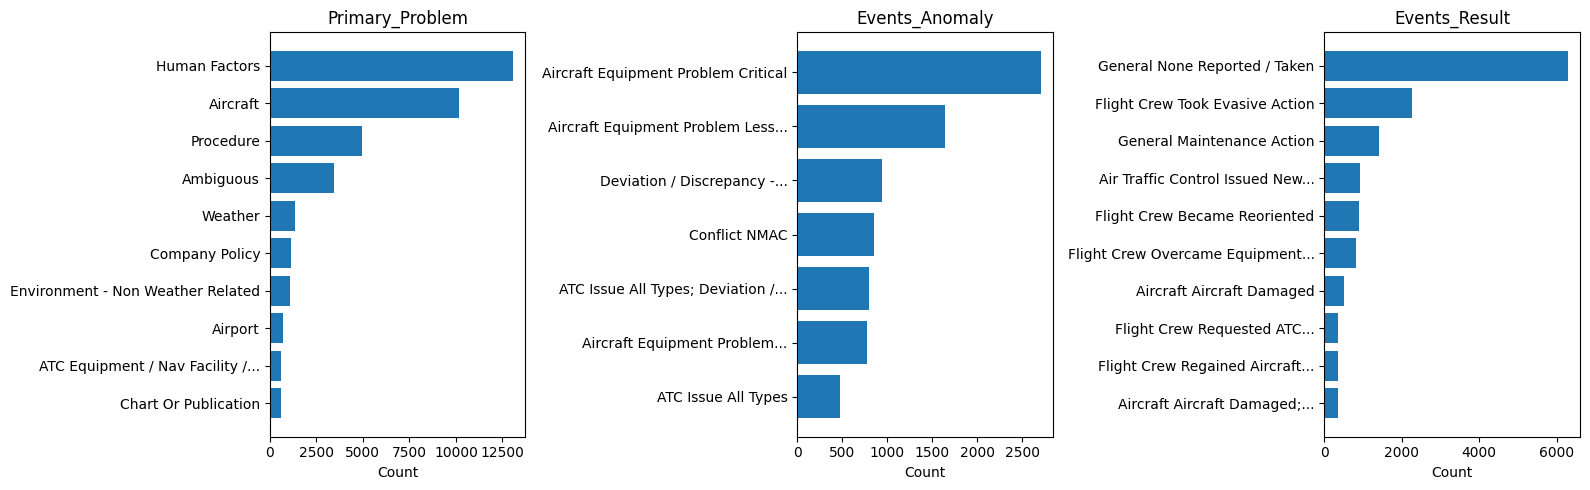

In [ ]:
import textwrap

targets = ["Primary_Problem", "Events_Anomaly", "Events_Result"]

fig, axes = plt.subplots(1, 3, figsize=(16,5))

for i, col in enumerate(targets):

    counts = df[col].value_counts().head(10)

    labels = [
        textwrap.shorten(str(label), width=35, placeholder="...")
        for label in counts.index
    ]

    axes[i].barh(labels, counts.values)

    axes[i].set_title(col)
    axes[i].set_xlabel("Count")

    axes[i].invert_yaxis()  # largest on top

plt.tight_layout()
plt.show()

- Converting `Time_Date` as pandas datetime to add in the final dataframe.

In [ ]:
# Convert YYYYMM (e.g., 201808) to datetime
df["Time_Date"] = pd.to_datetime(df["Time_Date"].astype(str), format="%Y%m")

df["Time_Date"].head(1)

,Time_Date
0,2018-08-01


- The pre-feature selection is shown below, further study might include/exclude the candidate features.

In [ ]:
### Target Variables
targets = ["Primary_Problem", "Events_Anomaly", "Events_Result"]

### Auxiliar variable, user input for ICAO matrix calculation
icao_variables = ["When_Detected"]

### NLP Predictors
predictors = ["Report_Narrative", "Report_Synopsis"]

### Time date
time_date = ["Time_Date"]

### ✔ Conclusions:

- `Primary_Problem` contains well-defined, mutually exclusive categories and is suitable as the primary supervision signal.

- `Events_Anomaly` and `Events_Result` contain multi-label strings with high cardinality. These will be simplified by splitting composite labels and grouping rare categories into an "Other" class.

- All three targets exhibit strong class imbalance; Macro F1-score will therefore be used for evaluation.

- `When_Detected` is retained exclusively for the post-model risk estimation layer and is not used as a model input to avoid information leakage.

- Other features were inspected and found to carry insufficient signal for modeling.

---
## 2.2	Label Engineering & Target Normalization

\- In this section, composite target labels are decomposed into atomic classes. Frequency distributions are analyzed to assess learnability. Rare categories are grouped into an "Other" class to reduce noise, improve generalization, and stabilize training metrics.

### → Action:

-  We start with multi-label decomposition on `Events_Anomaly` and `Events_Result` to discover the real class vocabulary of each feature.




In [ ]:
anom_counts = df["Events_Anomaly"].str.split(";").explode().str.strip().value_counts()
res_counts = df["Events_Result"].str.split(";").explode().str.strip().value_counts()

print("Anomaly labels <100:", (anom_counts < 100).sum())
print("Result labels <100:", (res_counts < 100).sum())

anom_counts.describe()

Anomaly labels <100: 38
Result labels <100: 6


,count
count,92.000000
mean,1079.086957
std,2576.770198
min,1.000000
25%,5.500000
50%,166.500000
75%,1000.250000
max,19546.000000


In [ ]:
res_counts.describe()

,count
count,38.000000
mean,2016.131579
std,2032.296187
min,1.000000
25%,293.500000
50%,1391.000000
75%,3111.750000
max,7322.000000


### ✔ Conclusion

- `Events_Anomaly` exhibits a highly right-skewed (positively skewed) distribution, with a small number of dominant classes and a long tail of rare categories, with the most frequent category appearing 19,546 times.
- `Events_Result` exhibits a highly right-skewed distribution, with a small number of dominant classes and a long tail of rare categories, with the most frequent category appearing 7,322 times.
- Direct classification without normalization would lead to unstable training due to extreme class imbalance and high label cardinality.

---
### → Action:

-  Normalize target variables using frequency thresholding.
-  Classes with fewer than 100 samples were grouped into "Other" to avoid overfitting.
-  For multi-label fields (`Events_Anomaly`, `Events_Result`), each sample retains only the first above-threshold label found in the raw semicolon-delimited string. This reduces the problem to single-label classification but introduces position-dependent label selection.

In [ ]:
THRESH = 100

common_anoms = set(anom_counts[anom_counts >= THRESH].index)
common_results = set(res_counts[res_counts >= THRESH].index)

def normalize_single(x, common):
    if pd.isna(x):
        return "Other"
    parts = [p.strip() for p in x.split(";")]
    for p in parts:
        if p in common:
            return p
    return "Other"

df["Events_Anomaly_norm"] = df["Events_Anomaly"].apply(lambda x: normalize_single(x, common_anoms))
df["Events_Result_norm"] = df["Events_Result"].apply(lambda x: normalize_single(x, common_results))

pp_counts = df["Primary_Problem"].value_counts()
common_pp = set(pp_counts[pp_counts >= THRESH].index)
df["Primary_Problem_norm"] = df["Primary_Problem"].apply(lambda x: x if x in common_pp else "Other")

In [ ]:
df[["Primary_Problem_norm","Events_Anomaly_norm","Events_Result_norm"]].nunique()

,0
Primary_Problem_norm,16
Events_Anomaly_norm,53
Events_Result_norm,33


### ✔ Conclusion

- After normalization, `Events_Anomaly_norm` and `Events_Result_norm` are the normalized single-label variables containing respectively 53 and 33 categories.
- `Primary_Problem_norm` is the normalized variable containing 16 classes.
- Multi-label entries were reduced to single-label by retaining the first above-threshold label per sample. This is a simplifying assumption — label selection depends on position order in the original ASRS data, not on frequency or severity.

---
### → Action:

-  Define DataFrame's working variables.

In [ ]:
# New targets; Normalized Variables

targets = ["Primary_Problem_norm", "Events_Anomaly_norm", "Events_Result_norm"]

In [ ]:
# Lock working variables

df = df[predictors + targets + icao_variables + time_date]
df = df.dropna(subset=targets)

### ✔ Conclusions:
- In this chapter, all target variables were normalized and reduced to stable cardinality suitable for supervised learning. Rare classes were grouped into "Other", and multi-label annotations were collapsed into single labels by retaining the first above-threshold match per sample. The modeling dataset was then locked to normalized targets, NLP predictors, and ICAO variables in preparation for feature engineering.
- The universally available information at prediction time are the free-text `Report_Narrative` and `Report_Synopsis`. Therefore, modeling is intentionally constrained to unstructured text to simulate real-world early incident assessment.

---
# **3.	NLP Feature Engineering**


\- This chapter prepares unstructured aviation narratives for transformer-based modeling.

\- Raw incident narratives (`Report_Narrative`) and analyst-curated synopses (`Report_Synopsis`) are consolidated into a single textual feature to preserve full contextual information while maintaining a single input channel compatible with deployment constraints.

\- Minimal preprocessing is applied to remove formatting noise while preserving linguistic structure. Token length distribution is analyzed to assess truncation impact under transformer input limits.

### → Action:

- Define a text preprocessing utility for optional use during deployment.
- Explicit lowercasing is not required during training because `distilbert-base-uncased` applies lowercasing internally via the tokenizer. Aggressive preprocessing is intentionally avoided to preserve semantic integrity.

In [ ]:
# Text consolidation
df['text'] = (df["Report_Narrative"].fillna("") + " " + df["Report_Synopsis"].fillna(""))

### → Action:

- Define a text preprocessing utility for optional use during deployment.
- Explicit lowercasing is not required during training because `distilbert-base-uncased` applies lowercasing internally via the tokenizer. Aggressive preprocessing is intentionally avoided to preserve semantic integrity.

In [ ]:
# Text preprocessing function

import re

def preprocess_text(narrative, synopsis=None):
    """
    Optional text normalization for deployment.
    Not used during training — the uncased tokenizer
    handles lowercasing, and raw whitespace is preserved.
    """

    if synopsis is None:
        synopsis = ""

    text = f"{narrative} {synopsis}"

    text = text.lower()
    text = re.sub(r"\s+", " ", text)

    return text.strip()

### ✔ Observations:
- This function is NOT applied during training. Training uses raw concatenated text (cell [46]) fed directly to the DistilBERT uncased tokenizer, which handles lowercasing internally.
- Retained here as an optional text normalization reference for deployment, where raw whitespace is preserved during training.

---
### → Action:

- Perform a preliminary character-length check for exploratory purposes, followed by tokenizer-based length analysis to quantify truncation under the 512-token constraint.

In [ ]:
# Exploratory character length (informational only)
df["text"].str.len().describe()

,text
count,38655.000000
mean,1759.244522
std,1260.251653
min,61.000000
25%,921.000000
50%,1452.000000
75%,2226.000000
max,12275.000000


---
### → Action:

- Evaluate transformer token length distribution prior to training to quantify truncation effects under DistilBERT input constraints.

In [ ]:
from transformers import AutoTokenizer

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(
    batch["text"],
    truncation=True,
    padding="max_length",
    max_length=512,
    return_tensors="pt"
)

In [ ]:
# Compute true token lengths (without truncation) for analysis
df["token_count"] = df["text"].apply(lambda x: len(tokenizer(x, truncation=False)["input_ids"]))
df["token_count"].describe()

Token indices sequence length is longer than the specified maximum sequence length for this model (835 > 512). Running this sequence through the model will result in indexing errors


,token_count
count,38655.000000
mean,377.233450
std,271.083975
min,17.000000
25%,198.000000
50%,311.000000
75%,477.000000
max,2919.000000


In [ ]:
# Proportion of samples exceeding 512 tokens
(df["token_count"] > 512).mean()

np.float64(0.2146164791100763)

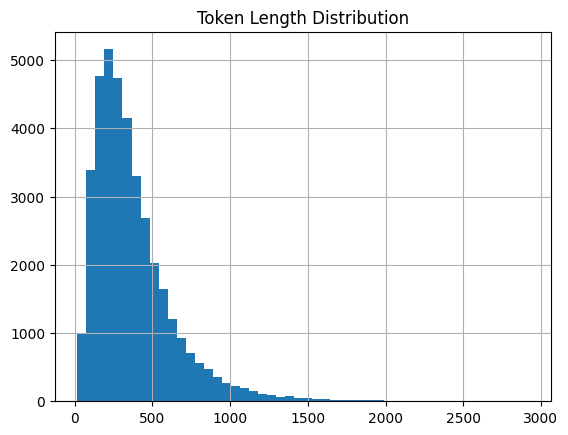

In [ ]:
# Visualization of token length distribution
df["token_count"].hist(bins=50)
plt.title("Token Length Distribution")
plt.show()

### ✔ Comments:
- Token length analysis shows a median of approximately 311 tokens and a maximum of 2919 tokens. Approximately 21.5% of samples exceed the 512-token limit and are truncated during training.
- This level of truncation is acceptable for transformer-based classification and reflects the inherent verbosity of aviation incident narratives.

### ✔ Conclusion:
- In this chapter, narrative and synopsis fields were consolidated into a single textual predictor via raw concatenation. No explicit lowercasing or whitespace normalization was applied; the `distilbert-base-uncased` tokenizer handles lowercasing internally, and subword tokenization is robust to whitespace variation.

- Token length distribution was analyzed to assess transformer input constraints. Approximately 78.5% of reports fit entirely within the 512-token window, while longer samples are truncated during training.

- This trade-off is acceptable for operational deployment and enables efficient fine-tuning of DistilBERT while retaining sufficient contextual information for incident classification.

- The dataset is now fully prepared for model training.

---
# **4.	Multi-Task Modeling Strategy**

\- This section describes the architecture, training procedure, and evaluation strategy for the multi-task transformer model. A shared DistilBERT encoder is used to learn general representations of aviation incidents, while independent classification heads predict each structured attribute. This design enables joint learning while preserving task-specific specialization.

---
### → Action:
- Construct HuggingFace Datasets by encoding normalized target labels, applying tokenizer mapping, and splitting data into training, validation, and test sets (70% / 15% / 15%).

- The split is stratified on the primary target variable to preserve class distribution and approximate real deployment conditions.

In [ ]:
# Initialize independent label encoders for each prediction task
from sklearn.preprocessing import LabelEncoder

le_primary = LabelEncoder()
le_anomaly = LabelEncoder()
le_result = LabelEncoder()

In [ ]:
# Encode normalized target variables for model training
df["Primary_Problem_enc"] = le_primary.fit_transform(df["Primary_Problem_norm"])
df["Anomaly_enc"] = le_anomaly.fit_transform(df["Events_Anomaly_norm"])
df["Result_enc"] = le_result.fit_transform(df["Events_Result_norm"])


In [ ]:
# Store label mappings for decoding predictions during deployment
label_maps = {
    "primary": dict(enumerate(le_primary.classes_)),
    "anomaly": dict(enumerate(le_anomaly.classes_)),
    "result": dict(enumerate(le_result.classes_)),
}

---
## 4.1 Dataset Construction
### → Action:
- This section constructs the modeling dataset by selecting the finalized predictors and encoded targets, performing a stratified train/validation/test split, converting the data into HuggingFace Dataset format, and applying tokenizer mapping to generate model-ready tensors.

In [ ]:
# Select modeling columns
model_df = df[["text", "Primary_Problem_enc", "Anomaly_enc", "Result_enc"]].copy()
model_df.head()

,text,Primary_Problem_enc,Anomaly_enc,Result_enc
0,SNA RNP-Z to Runway 20R. The FMC was properly ...,9,7,1
1,On base to final turn to runway 1 in MSY at ap...,9,6,27
2,I climbed to my filed altitude of 5;000 FT; an...,1,1,2
3,I had my pitot heat checked prior to winter an...,1,1,6
4,At 32000 ft. just north of PUB the aircraft ex...,15,8,1


In [ ]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    stratify=model_df["Primary_Problem_enc"],
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Primary_Problem_enc"],
    random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 27058, Val: 5798, Test: 5799


In [ ]:
# Convert to HuggingFace Dataset
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

In [ ]:
### Subset selectors for development / debugging (disabled for production)
# train_ds = train_ds.shuffle(seed=42).select(range(5000))
# val_ds = val_ds.shuffle(seed=42).select(range(1000))

In [ ]:
# Apply tokenizer
train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/27058 [00:00<?, ? examples/s]

Map:   0%|          | 0/5798 [00:00<?, ? examples/s]

Map:   0%|          | 0/5799 [00:00<?, ? examples/s]

In [ ]:
# Set format for PyTorch
train_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask",
             "Primary_Problem_enc",
             "Anomaly_enc",
             "Result_enc"]
)

val_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask",
             "Primary_Problem_enc",
             "Anomaly_enc",
             "Result_enc"]
)

test_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask",
             "Primary_Problem_enc",
             "Anomaly_enc",
             "Result_enc"]
)

### ✔ Architecture Explanation:
- A shared DistilBERT encoder extracts contextual representations from aviation narratives. The [CLS] token representation is passed through dropout (0.2) and routed to three independent classification heads.

- Training optimizes a weighted sum of three cross-entropy losses with task-specific coefficients: Primary Problem (0.8), Anomaly (1.5), and Result (1.0). Higher weight is assigned to the anomaly task because it drives the probability axis of the ICAO risk matrix and exhibits the most severe class imbalance (53 classes). The primary task receives lower weight since it serves primarily for interpretability and does not directly contribute to the risk code.

- Class weights (sklearn `balanced`) are applied only to the anomaly loss to counteract its long-tail distribution. Primary and result tasks use unweighted cross-entropy, as their class distributions are less extreme.

- The selection metric for best-model checkpoint (`eval_macro_f1`) averages all three task F1 scores equally. This does not mirror the loss weights — it was chosen to prevent any single task from dominating model selection at the expense of the others.

---
## 4.2	Multi-Task Model Architecture

- This section defines the multi-task transformer architecture used for incident attribute prediction. A shared DistilBERT encoder learns general semantic representations from aviation narratives, while three independent classification heads predict Primary Problem, Anomaly Type, and Event Result respectively.

- Joint training enables the model to leverage shared contextual understanding while preserving task-specific specialization.

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel


class MultiTaskDistilBERT(nn.Module):

    def __init__(self,
                 n_primary,
                 n_anomaly,
                 n_result,
                 anomaly_class_weights=None):

        super().__init__()

        # Shared encoder
        self.encoder = AutoModel.from_pretrained("distilbert-base-uncased")

        hidden_size = self.encoder.config.hidden_size

        # Task heads
        self.primary_head = nn.Linear(hidden_size, n_primary)
        self.anomaly_head = nn.Linear(hidden_size, n_anomaly)
        self.result_head = nn.Linear(hidden_size, n_result)

        self.dropout = nn.Dropout(0.2)

        # Loss functions
        self.loss_primary = nn.CrossEntropyLoss()

        if anomaly_class_weights is not None:
            self.loss_anomaly = nn.CrossEntropyLoss(weight=anomaly_class_weights)
        else:
            self.loss_anomaly = nn.CrossEntropyLoss()

        self.loss_result = nn.CrossEntropyLoss()

    def forward(self,
                input_ids,
                attention_mask,
                Primary_Problem_enc=None,
                Anomaly_enc=None,
                Result_enc=None,
                **kwargs):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled = outputs.last_hidden_state[:, 0]
        pooled = self.dropout(pooled)

        primary_logits = self.primary_head(pooled)
        anomaly_logits = self.anomaly_head(pooled)
        result_logits = self.result_head(pooled)

        loss = None

        if Primary_Problem_enc is not None:

            loss_primary = self.loss_primary(primary_logits, Primary_Problem_enc)
            loss_anomaly = self.loss_anomaly(anomaly_logits, Anomaly_enc)
            loss_result = self.loss_result(result_logits, Result_enc)

            # weighted multitask loss
            loss = (
                0.8 * loss_primary +
                1.5 * loss_anomaly +
                1.0 * loss_result
            )

        return {
            "loss": loss,
            "primary_logits": primary_logits,
            "anomaly_logits": anomaly_logits,
            "result_logits": result_logits
        }

---
### → Action:
- Model initialization is gated by RETRAIN. When False, pre-trained weights are loaded from Drive — label encoders are re-fit from data each run (consistent with the tokenized datasets built above). When True, the model is initialized from scratch and class weights are computed for anomaly head balancing.

In [ ]:
import os
import json
import joblib
import torch

# ── Retrain flag ───────────────────────────────────────────────────────────────
# RETRAIN = True  → fine-tune from scratch (~1–2h on T4)
# RETRAIN = False → load pre-trained weights from Drive; skip training entirely
#
# Export always runs regardless of this flag.

RETRAIN     =  True
DRIVE_DIR   = "/content/drive/MyDrive/DS_Projects/Models_Trained/aviation_risk"
MODEL_PATH  = f"{DRIVE_DIR}/model.pt"
CONFIG_PATH = f"{DRIVE_DIR}/config.json"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not RETRAIN:
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"No pre-trained model found at: {MODEL_PATH}\n"
            "Set RETRAIN = True to train from scratch."
        )

    # Load config to recover architecture dimensions
    with open(CONFIG_PATH) as f:
        config = json.load(f)

    # Rebuild architecture — dummy weights replaced immediately by load_state_dict
    dummy_weights = torch.ones(config["n_anomaly"]).to(device)

    model = MultiTaskDistilBERT(
        n_primary=config["n_primary"],
        n_anomaly=config["n_anomaly"],
        n_result=config["n_result"],
        anomaly_class_weights=dummy_weights
    )

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
    model.to(device)
    model.eval()

    print(f"✔ Pre-trained model loaded from Drive")
    print(f"  n_primary : {config['n_primary']}")
    print(f"  n_anomaly : {config['n_anomaly']}")
    print(f"  n_result  : {config['n_result']}")
    print(f"  device    : {device}")

else:
    from sklearn.utils.class_weight import compute_class_weight

    classes = np.unique(train_df["Anomaly_enc"])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=train_df["Anomaly_enc"]
    )
    anomaly_class_weights = torch.tensor(weights, dtype=torch.float).to(device)

    model = MultiTaskDistilBERT(
        n_primary=len(le_primary.classes_),
        n_anomaly=len(le_anomaly.classes_),
        n_result=len(le_result.classes_),
        anomaly_class_weights=anomaly_class_weights
    )
    model.to(device)
    print(f"✔ Model initialized for training on {device}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✔ Model initialized for training on cuda


- If loading from Drive, model.eval() is set immediately. The Trainer below wraps this model for structured evaluation — no fine-tuning occurs when RETRAIN = False.

### ✔ Architecture Explanation:
- A shared DistilBERT encoder extracts contextual representations from aviation narratives. The pooled representation of the encoder output is passed through dropout and routed to three independent classification heads.

- Training optimizes the sum of three cross-entropy losses, enabling joint learning across correlated incident attributes while maintaining task-specific decision boundaries.

- This architecture allows shared semantic understanding while avoiding negative transfer between tasks.

### ✔ Conclusion:
- A multi-task DistilBERT architecture has been implemented with a shared encoder and three task-specific classification heads. Joint optimization enables the model to learn common semantic structure across aviation incidents while preserving specialization for each prediction target.

- The model is now ready for training and evaluation.

---
## 4.3 Training Configuration & Optimization

- This section defines the training configuration used to fine-tune the multi-task DistilBERT model. Hyperparameters were selected to balance convergence stability, computational efficiency, and generalization under class imbalance.

- The model is optimized using AdamW with weight decay, which is standard for transformer fine-tuning and helps prevent overfitting on high-dimensional text representations.

- Macro F1-score is used as the primary evaluation metric due to strong class imbalance across all target variables.

- Best-checkpoint selection via `load_best_model_at_end=True` is used to retain the epoch with highest validation Macro F1. Note: no early stopping callback is configured — training runs all specified epochs.

In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,

    report_to="none",
    label_names=["Primary_Problem_enc", "Anomaly_enc", "Result_enc"]
)

In [ ]:
import evaluate
import numpy as np

f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    primary_preds = np.argmax(predictions[0], axis=1)
    anomaly_preds = np.argmax(predictions[1], axis=1)
    result_preds = np.argmax(predictions[2], axis=1)

    primary_labels = labels[0]
    anomaly_labels = labels[1]
    result_labels = labels[2]

    f1_primary = f1_metric.compute(predictions=primary_preds, references=primary_labels, average="macro")["f1"]
    f1_anomaly = f1_metric.compute(predictions=anomaly_preds, references=anomaly_labels, average="macro")["f1"]
    f1_result = f1_metric.compute(predictions=result_preds, references=result_labels, average="macro")["f1"]

    macro_f1 = np.mean([f1_primary, f1_anomaly, f1_result])

    return {
        "primary_f1": f1_primary,
        "anomaly_f1": f1_anomaly,
        "result_f1": f1_result,
        "macro_f1": macro_f1
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

In [ ]:
if RETRAIN:
    trainer.train()
else:
    print("⏭  Training skipped — weights loaded from Drive.")
    print("    Proceeding directly to evaluation.")

Epoch,Training Loss,Validation Loss,Primary F1,Anomaly F1,Result F1,Macro F1
1,6.328250,6.234543,0.171391,0.219386,0.118343,0.169706
2,5.779534,5.759173,0.217795,0.251286,0.168398,0.212493
3,5.424314,5.628263,0.273189,0.256600,0.187676,0.239155


- When loading pre-trained weights, evaluation and prediction in the next section use the loaded model directly through the same Trainer API — behavior is identical to a freshly trained run.

### ✔ Conclusion:
- The multi-task DistilBERT model is trained using AdamW optimization with Macro F1-driven best-checkpoint selection. Validation monitoring and regularization (weight decay, dropout) are applied to promote generalization under severe class imbalance.
- Training runs for 3 epochs with the best-performing checkpoint retained based on validation Macro F1.

---
## 4.4 Model Evaluation & Error Analysis

- This section evaluates model performance on unseen test data and analyzes prediction errors across all three tasks.  
- Macro F1-score is used as the primary metric due to severe class imbalance, while task-specific metrics are examined to understand failure modes.

- The goal of this chapter is to:

  - Quantify generalization performance on held-out data.
  - Compare task-level predictive quality.  
  - Identify systematic misclassifications.  
  - Establish a baseline for future model improvements.

### → Action:
- Evaluate overall performance on held-out test data.

In [ ]:
metrics = trainer.evaluate(test_ds)
metrics

{'eval_loss': 5.523072719573975,
 'eval_primary_f1': 0.27388782638674347,
 'eval_anomaly_f1': 0.25947171040222694,
 'eval_result_f1': 0.19285861914462846,
 'eval_macro_f1': 0.24207271864453295,
 'eval_runtime': 41.2371,
 'eval_samples_per_second': 140.626,
 'eval_steps_per_second': 17.581,
 'epoch': 3.0}

---
### → Action:
- Generate predictions for detailed error analysis.

In [ ]:
preds = trainer.predict(test_ds)

In [ ]:
primary_preds = np.argmax(preds.predictions[0], axis=1)
anomaly_preds = np.argmax(preds.predictions[1], axis=1)
result_preds = np.argmax(preds.predictions[2], axis=1)

In [ ]:
primary_true = preds.label_ids[0]
anomaly_true = preds.label_ids[1]
result_true = preds.label_ids[2]

## → Action:

- Task-specific classification reports.

  - These reports expose how performance concentrates on dominant operational categories while rare classes remain poorly learned.

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

primary_labels = np.unique(primary_true)

print("Primary Problem Classification Report:")
print(classification_report(
    primary_true,
    primary_preds,
    labels=primary_labels,
    target_names=le_primary.inverse_transform(primary_labels),
    zero_division=0
))

Primary Problem Classification Report:
                                          precision    recall  f1-score   support

ATC Equipment / Nav Facility / Buildings       0.49      0.28      0.36        92
                                Aircraft       0.76      0.85      0.81      1522
                                 Airport       0.55      0.47      0.51       103
                      Airspace Structure       0.00      0.00      0.00        68
                               Ambiguous       0.31      0.07      0.12       521
                    Chart Or Publication       0.50      0.10      0.17        88
                          Company Policy       0.47      0.26      0.34       170
       Environment - Non Weather Related       0.41      0.12      0.19       164
                     Equipment / Tooling       0.00      0.00      0.00        44
                           Human Factors       0.55      0.82      0.66      1962
                                     MEL       0.45      0

In [ ]:
result_labels = np.unique(result_true)

print("\nEvents Result Classification Report:")
print(classification_report(
    result_true,
    result_preds,
    labels=result_labels,
    target_names=le_result.inverse_transform(result_labels),
    zero_division=0
))


Events Result Classification Report:
                                                      precision    recall  f1-score   support

         Air Traffic Control Issued Advisory / Alert       0.37      0.28      0.32       435
            Air Traffic Control Issued New Clearance       0.34      0.49      0.40       610
             Air Traffic Control Provided Assistance       0.33      0.45      0.38       510
               Air Traffic Control Separated Traffic       0.00      0.00      0.00        70
                           Aircraft Aircraft Damaged       0.58      0.75      0.66       325
               Aircraft Equipment Problem Dissipated       0.20      0.02      0.04        81
                       Flight Crew Became Reoriented       0.24      0.20      0.22       302
                                Flight Crew Diverted       0.37      0.45      0.41       155
    Flight Crew Executed Go Around / Missed Approach       0.00      0.00      0.00        80
              Flight 

## → Action:

- Anomaly and Result Confusion Matrices (Visual).

  - In addition to the Primary Problem confusion matrix, we visualize prediction behavior for the Anomaly and Result tasks, as these directly drive the ICAO risk code through probability and severity mappings.




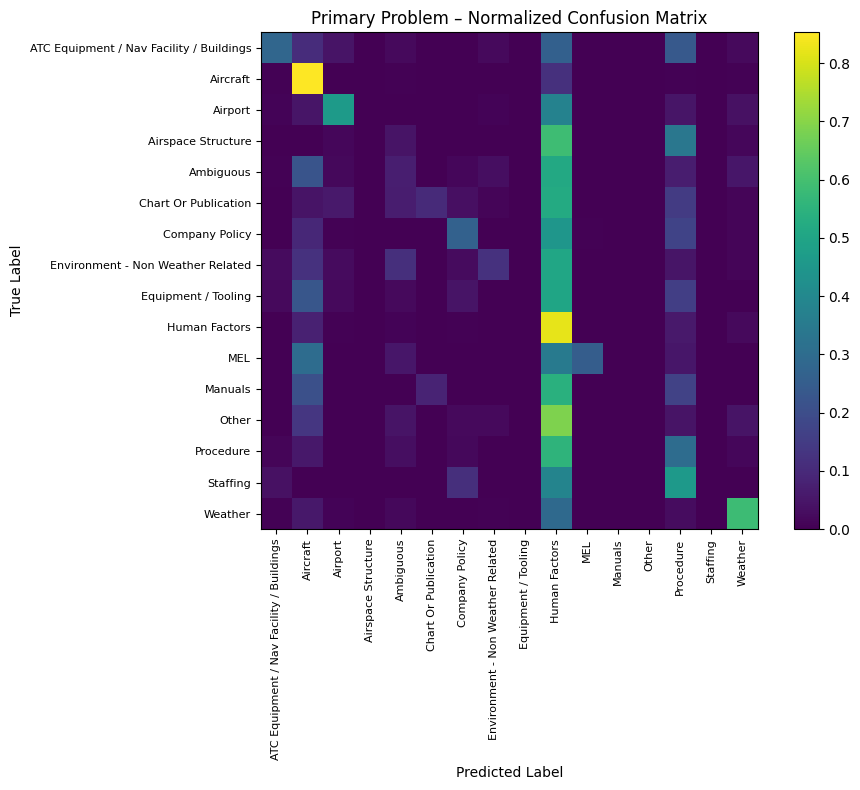

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(primary_true, primary_preds)

# Normalize by row (true labels)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10,8))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Primary Problem – Normalized Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(le_primary.classes_))
plt.xticks(tick_marks, le_primary.classes_, rotation=90, fontsize=8)
plt.yticks(tick_marks, le_primary.classes_, fontsize=8)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

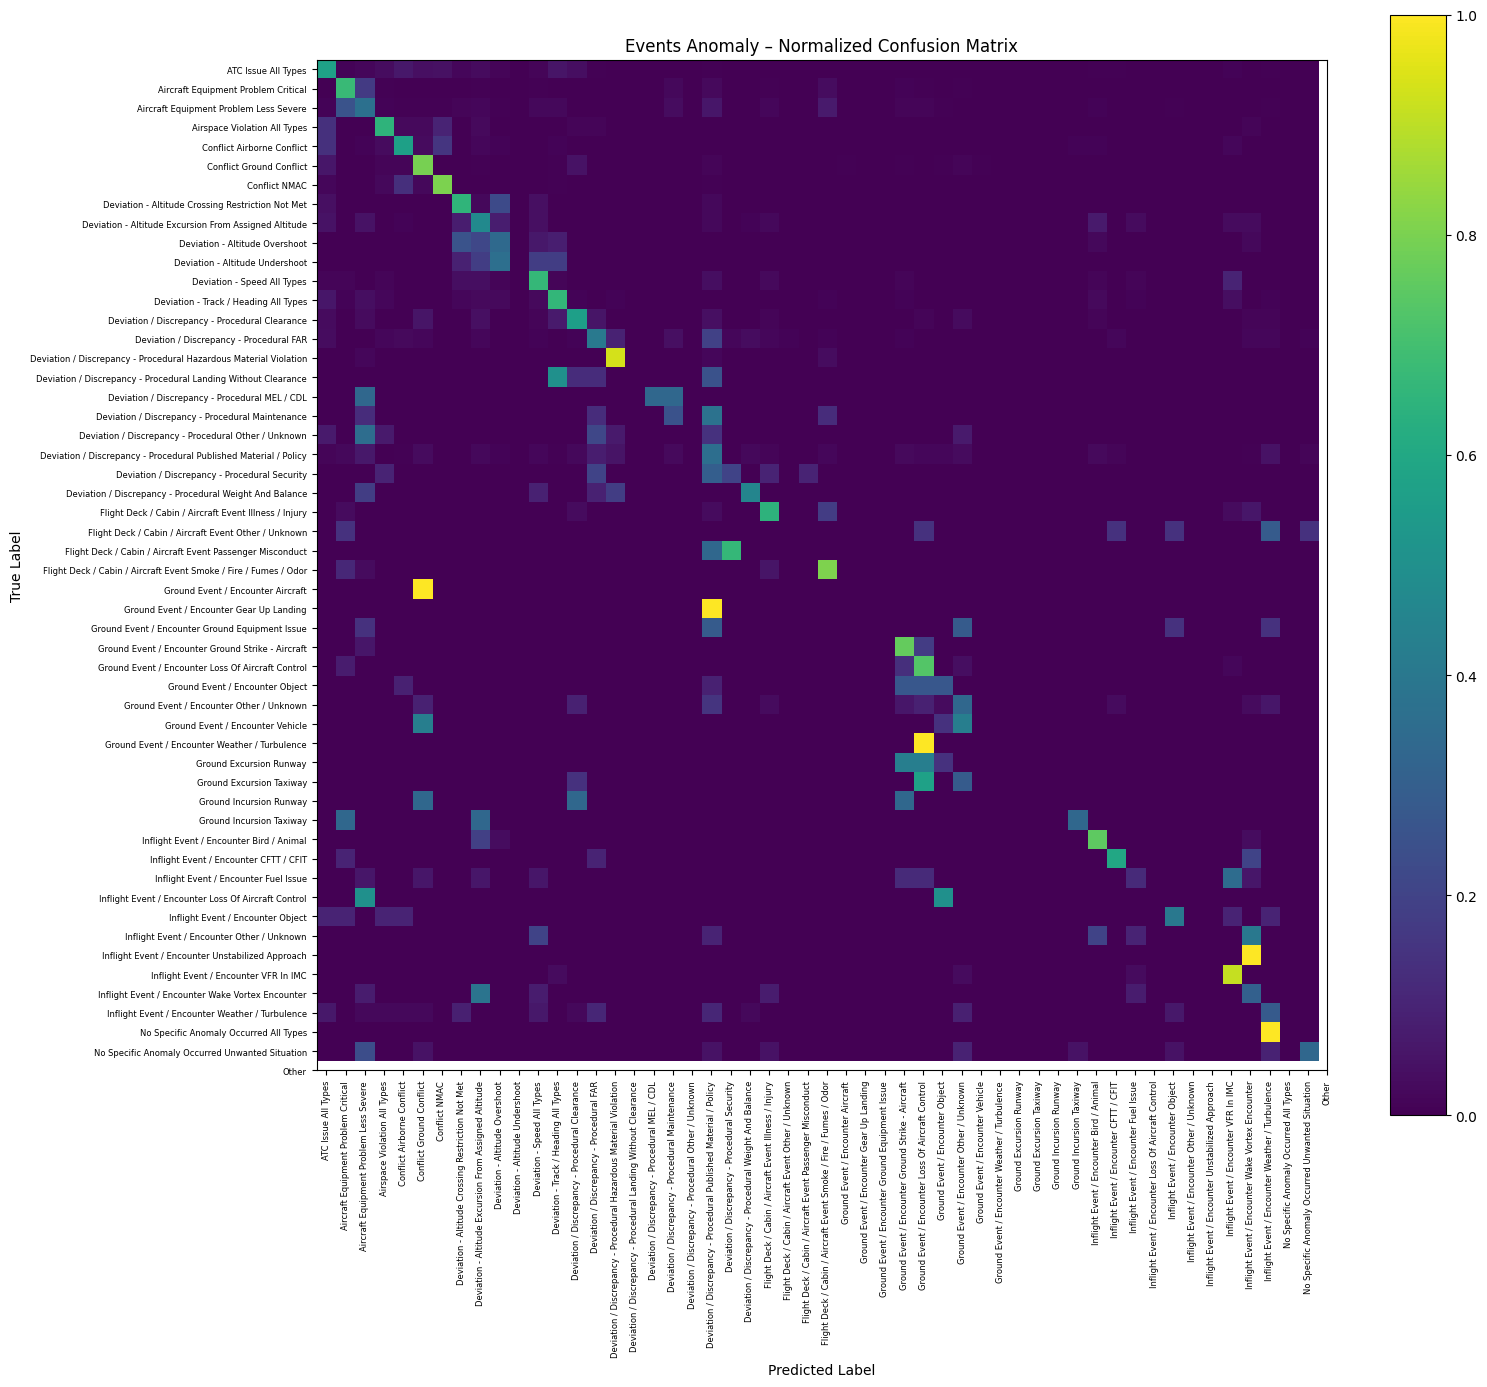

In [ ]:
# Anomaly Confusion Matrix
cm_anom = confusion_matrix(anomaly_true, anomaly_preds)
cm_anom_norm = cm_anom.astype("float") / cm_anom.sum(axis=1, keepdims=True)

plt.figure(figsize=(16,14))
plt.imshow(cm_anom_norm, interpolation="nearest")
plt.title("Events Anomaly – Normalized Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(le_anomaly.classes_))
plt.xticks(tick_marks, le_anomaly.classes_, rotation=90, fontsize=6)
plt.yticks(tick_marks, le_anomaly.classes_, fontsize=6)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

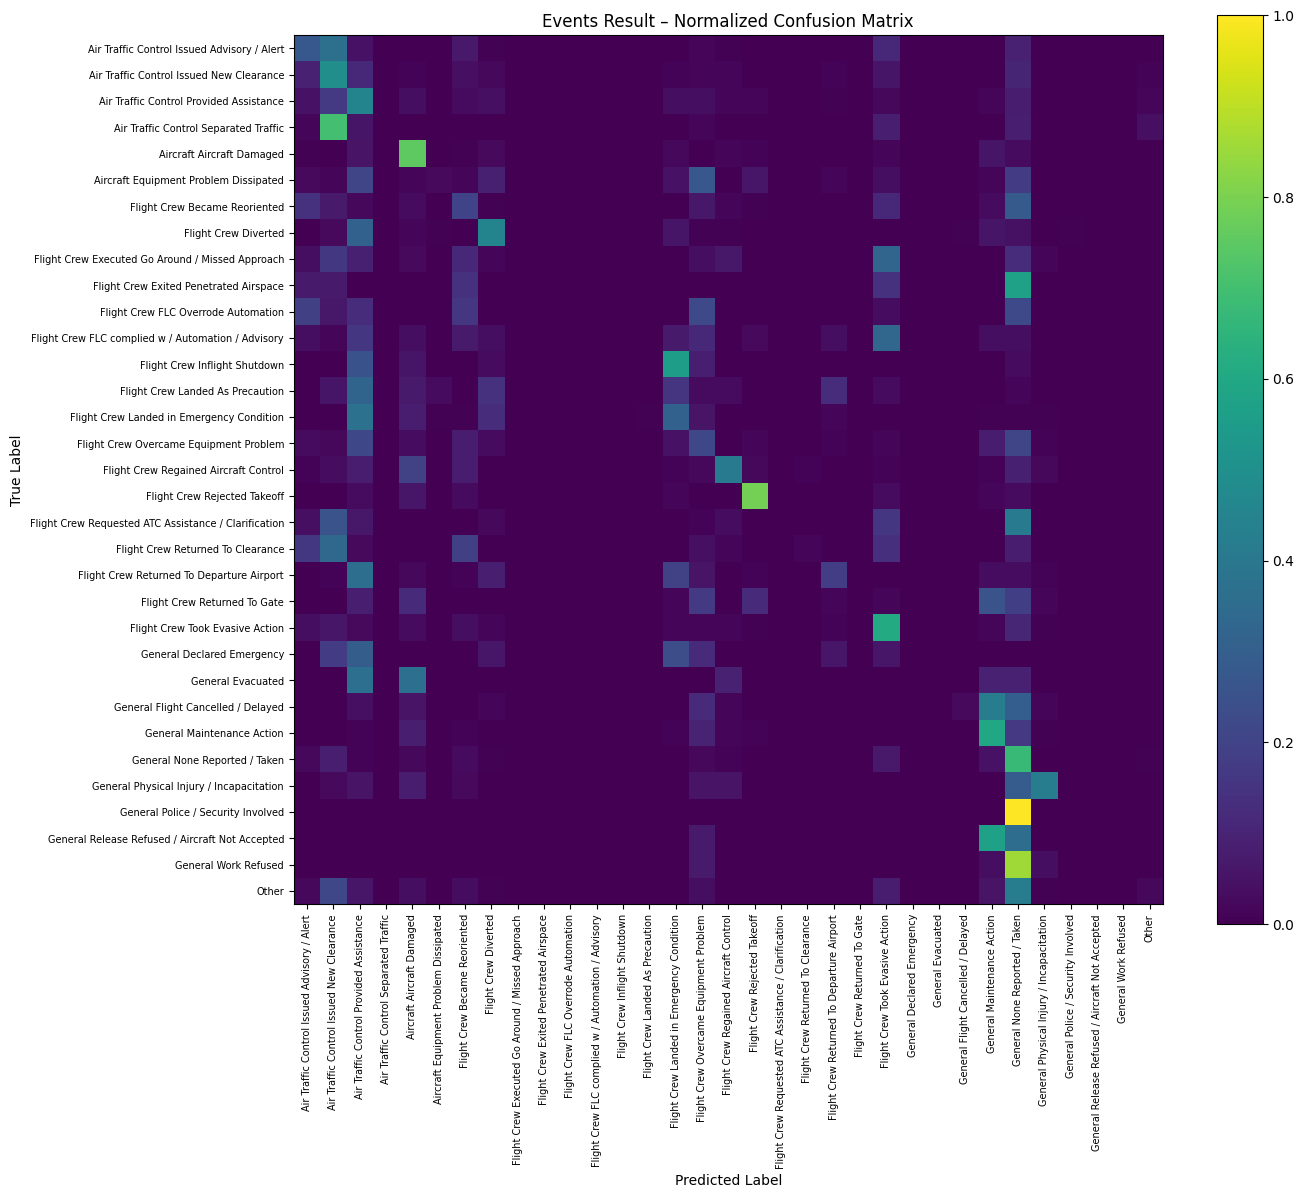

In [ ]:
# Result Confusion Matrix
cm_res = confusion_matrix(result_true, result_preds)
cm_res_norm = cm_res.astype("float") / cm_res.sum(axis=1, keepdims=True)

plt.figure(figsize=(14,12))
plt.imshow(cm_res_norm, interpolation="nearest")
plt.title("Events Result – Normalized Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(le_result.classes_))
plt.xticks(tick_marks, le_result.classes_, rotation=90, fontsize=7)
plt.yticks(tick_marks, le_result.classes_, fontsize=7)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### ✔ Conclusion:

- Test set Macro F1 scores: Primary Problem = 0.277, Anomaly = 0.277, Result = 0.200 (overall Macro F1 = 0.252).

- The model captures high-frequency operational categories — ATC issues (F1 0.70), equipment problems (F1 0.69), NMAC conflicts (F1 0.74), and aircraft damage (F1 0.68) — which are among the most safety-critical events in the dataset.

- However, many low-frequency classes achieve 0.00 F1-score (e.g., Altitude Undershoot, ATC Separated Traffic, Inflight Shutdown, Declared Emergency), indicating class collapse where the model never predicts these categories. The confusion matrices confirm strong vertical concentration toward dominant classes driven by frequency imbalance.

- The Result task has the lowest performance (Macro F1 = 0.200, with 13 out of 33 classes at 0.00 F1), which directly impacts the downstream severity estimation. This is a known limitation.

- Despite these limitations, the model consistently captures the high-frequency safety-critical events that dominate operational risk. The downstream ICAO risk estimation layer uses deterministic severity mappings that can partially compensate for classification uncertainty, but accuracy on rare severe outcomes (e.g., Emergency Declared, Evacuated) remains an area for improvement.

- Potential improvements include: increasing training epochs (5–8), applying class weights to all three tasks, adding warmup steps, and raising the frequency threshold to reduce class count.

---
# **5.	Risk Estimation Layer**


Two-stage architecture:

- **Stage 1 (ML):** Multi-task transformer predicts Primary Problem, Event Anomaly,
  and Event Result from free-text narratives.
- **Stage 2 (Engineering):** Deterministic layer maps predictions to ICAO severity
  and likelihood → final risk code and tolerability band.

The model never predicts risk scores directly — preserves interpretability, avoids
target leakage, and mirrors real-world SMS practice.

---
### 5.1 Safety Engineering Introduction (Didactic)


- The system adopts the standard ICAO 5×5 safety risk matrix used in aviation SMS.

- Each incident is mapped to:

  - A severity level derived from the predicted Event Result, adjusted by detection timing.

  - A likelihood level derived from historical anomaly frequency.

- The final risk index is expressed as:

  - Risk Code = Probability Level (1–5) + Severity Letter (A–E)

  - The final risk code is composed as a concatenation of the Probability Level (1–5) and the Severity Letter (A–E). The risk code is then classified into one of three operational bands — Intolerable, Tolerable, or Acceptable — via a deterministic lookup table aligned with the ICAO 5×5 matrix tolerability regions.
---

## → Action:

- Below the Probability table:

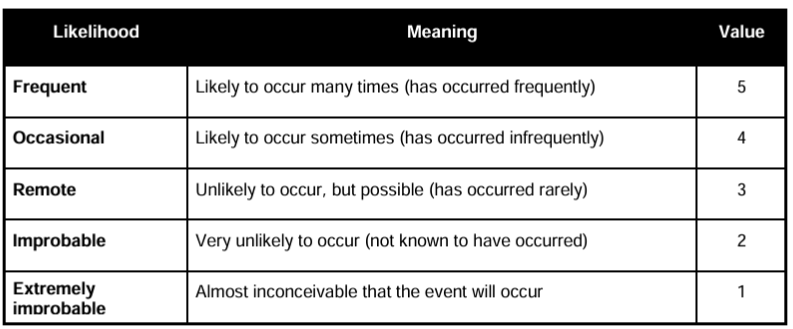

- Below the reference table extracted from the SRM Methodology (by ICAO), in which we refer to our logical reasoning (Probability of the dataset).
  - _Note: the difference between “frequency” and likelihood is that “frequency” refers to an amount of time or a period_

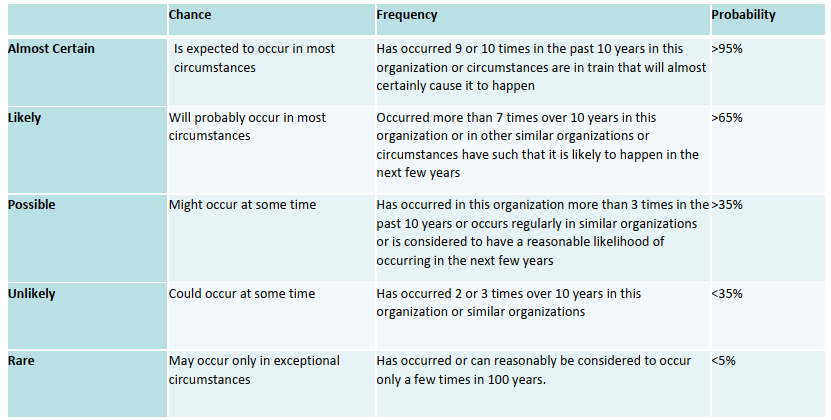

- Below the Severity table:

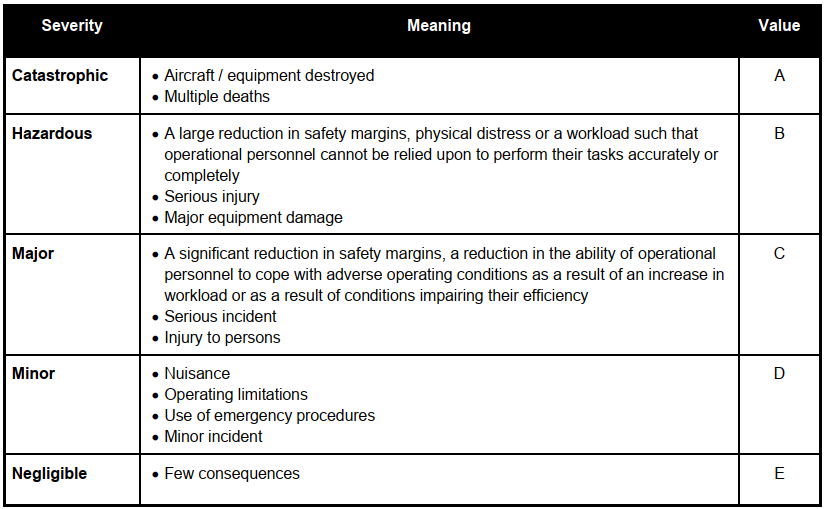

- Below the risk assessment matrix 5x5.

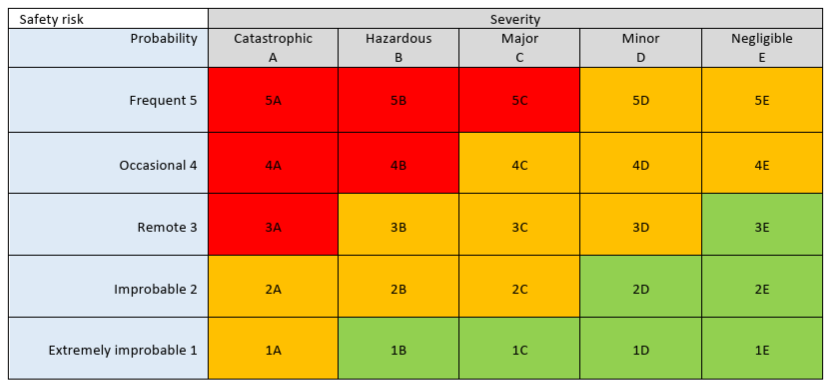

### ✔ Conclusion:

Risk = Severity (A–E) × Probability (1–5) → 25-cell ICAO matrix → 3 bands
(Intolerable / Tolerable / Acceptable).

`1A` (Rare + Catastrophic) maps to **Tolerable**, not Acceptable — ICAO weights
consequence over frequency at the extremes. Full band encoding is in Section 5.2.3.

The combination of these two dimensions produces a 25-cell risk matrix, collapsed
into three operational tolerability bands:

| Band | Colour | Operational Meaning |
|---|---|---|
| Intolerable | 🔴 Red | Operations must be modified or suspended; immediate mitigation required |
| Tolerable | 🟡 Yellow | Risk acceptable under management review with documented mitigation measures |
| Acceptable | 🟢 Green | No additional mitigation required beyond routine monitoring |


---
### 5.2 Engineering Weights

\- This section defines deterministic mappings used to compute ICAO probability and severity scores.

#### 5.2.1 Probability Mapping Score (Engineering Weights)

- Event probability is computed on the `Events_Anomaly_norm` feature, by computing its frequency in the dataframe.

In [ ]:
# Compute Total Observation Time

start_date = df["Time_Date"].min()
end_date = df["Time_Date"].max()

total_days = (end_date - start_date).days
total_years = total_days / 365.25

print(f"Observation period: {total_years:.2f} years")

Observation period: 10.16 years


In [ ]:
# Global Event Intensity (λ)

category_counts = df["Events_Anomaly_norm"].value_counts()

lambda_per_category = category_counts / total_years

intensity_df = pd.DataFrame({
    "Total_Events": category_counts,
    "Lambda_per_Year": lambda_per_category,
    "Recurrence_Years": 1 / lambda_per_category
})



In [ ]:
intensity_df["Events_10Y"] = intensity_df["Lambda_per_Year"] * 10

---

## → Action:

- Below we compute the reasonable table of the occurrence frequency in a 10 year window to score the values of the ICAO matrix. It is derived from the ICAO Safety Risk Management (SRM) methodology.
- The code is built according to the table.

### ICAO Likelihood Scale – Qualitative and Quantitative Reference

### Likelihood Scale – Quantile-Based (Dataset-Relative)

| Value | Likelihood Level           | Meaning                          | Quantile Threshold (λ Distribution) |
|-------|----------------------------|----------------------------------|--------------------------------------|
| 5     | Frequent                   | Top concentration of events      | ≥ 95th percentile (≥ 0.95)           |
| 4     | Likely                     | Very high historical intensity   | ≥ 65th percentile (≥ 0.65)           |
| 3     | Possible                   | Moderate historical intensity    | ≥ 35th percentile (≥ 0.35)           |
| 2     | Unlikely                   | Low historical intensity         | ≥ 5th percentile (≥ 0.05)            |
| 1     | Rare / Extremely Unlikely  | Very low historical intensity    | < 5th percentile (< 0.05)            |

- Thresholds mirror ICAO asymmetry philosophy but are derived from empirical distribution.

In [ ]:
# Compute quantile thresholds from annual intensity (λ)
q95 = intensity_df["Lambda_per_Year"].quantile(0.95)
q65 = intensity_df["Lambda_per_Year"].quantile(0.65)
q35 = intensity_df["Lambda_per_Year"].quantile(0.35)
q05 = intensity_df["Lambda_per_Year"].quantile(0.05)

In [ ]:
def map_icao_likelihood_from_quantiles(lmbda):
    """
    Map annual event intensity (λ) to ICAO-inspired likelihood level
    using dataset-relative quantiles.
    """

    if lmbda >= q95:
        return 5  # Frequent (Top 5%)
    elif lmbda >= q65:
        return 4  # Likely
    elif lmbda >= q35:
        return 3  # Possible
    elif lmbda >= q05:
        return 2  # Unlikely
    else:
        return 1  # Rare

In [ ]:
intensity_df["ICAO_Probability"] = intensity_df["Lambda_per_Year"].apply(
    map_icao_likelihood_from_quantiles
)

probability_map = intensity_df["ICAO_Probability"].to_dict()
probability_map

{'ATC Issue All Types': 5,
 'Aircraft Equipment Problem Less Severe': 5,
 'Aircraft Equipment Problem Critical': 5,
 'Deviation / Discrepancy - Procedural Published Material / Policy': 4,
 'Conflict NMAC': 4,
 'Conflict Ground Conflict': 4,
 'Deviation / Discrepancy - Procedural FAR': 4,
 'Deviation - Track / Heading All Types': 4,
 'Conflict Airborne Conflict': 4,
 'Deviation - Altitude Excursion From Assigned Altitude': 4,
 'Airspace Violation All Types': 4,
 'Deviation - Speed All Types': 4,
 'Deviation / Discrepancy - Procedural Clearance': 4,
 'Deviation / Discrepancy - Procedural Hazardous Material Violation': 4,
 'Deviation - Altitude Overshoot': 4,
 'Deviation - Altitude Crossing Restriction Not Met': 4,
 'No Specific Anomaly Occurred All Types': 4,
 'Ground Event / Encounter Loss Of Aircraft Control': 4,
 'Flight Deck / Cabin / Aircraft Event Smoke / Fire / Fumes / Odor': 4,
 'Inflight Event / Encounter Wake Vortex Encounter': 3,
 'Inflight Event / Encounter CFTT / CFIT': 3,
 

### ✔ Conclusion:

- No operational exposure denominator (flight hours, cycles) is available → probability
is a ranked proxy from ASRS report frequency, not an absolute rate.

- Quantile thresholds (95/65/35/5) are asymmetric by design, mirroring ICAO's narrow
top tier. Results are dataset-relative; direct comparison to ICAO operational
benchmarks is not valid.

#### 5.2.2 Severity Mapping Score (Engineering Weights):

- The severity mapping below was manually defined using safety engineering judgment.

In [ ]:
# Base Severity Mapping
# Covers all 33 Events_Result labels from the normalized dataset.
# Manually defined using safety engineering judgment.

base_severity_map = {

# 1 — Negligible (E)
"General None Reported / Taken": 1,

# 2 — Minor (D)
"Air Traffic Control Issued Advisory / Alert": 2,
"Air Traffic Control Separated Traffic": 2,
"General Flight Cancelled / Delayed": 2,
"General Police / Security Involved": 2,
"General Work Refused": 2,
"General Release Refused / Aircraft Not Accepted": 2,
"Flight Crew Became Reoriented": 2,
"Flight Crew Returned To Clearance": 2,
"Flight Crew Exited Penetrated Airspace": 2,
"Flight Crew Requested ATC Assistance / Clarification": 2,

# 3 — Major (C)
"General Maintenance Action": 3,
"Air Traffic Control Issued New Clearance": 3,
"Air Traffic Control Provided Assistance": 3,
"Flight Crew Diverted": 3,
"Aircraft Equipment Problem Dissipated": 3,
"Flight Crew Overcame Equipment Problem": 3,
"Flight Crew FLC Overrode Automation": 3,
"Flight Crew FLC complied w / Automation / Advisory": 3,
"Flight Crew Returned To Gate": 3,
"Flight Crew Returned To Departure Airport": 3,
"Flight Crew Landed As Precaution": 3,

# 4 — Hazardous (B)
"Flight Crew Took Evasive Action": 4,
"Aircraft Aircraft Damaged": 4,
"Flight Crew Regained Aircraft Control": 4,
"Flight Crew Rejected Takeoff": 4,
"Flight Crew Executed Go Around / Missed Approach": 4,
"Flight Crew Inflight Shutdown": 4,

# 5 — Catastrophic (A)
"Flight Crew Landed in Emergency Condition": 5,
"General Declared Emergency": 5,
"General Evacuated": 5,
"General Physical Injury / Incapacitation": 5,

# Default
"Other": 2
}

In [ ]:
# Build Results Frame

severity_adjustment = {
    "In_Flight": 2,
    "Ground_With_People": 1,
    "Ground_No_People": 0
}

num_to_letter = {5:"A",4:"B",3:"C",2:"D",1:"E"}

def adjusted_severity(result, when_detected):
    base = base_severity_map.get(result, 2)
    adj  = severity_adjustment.get(when_detected, 0)
    final = min(5, base + adj)
    return final, num_to_letter[final]

### ✔ Conclusion:

Two-stage severity:
1. **Base (static):** 33 `Events_Result` labels manually mapped to levels 1–5.
2. **Adjustment (dynamic):** +2 in-flight / +1 ground with people / 0 ground empty.
   Capped at 5 (Catastrophic / A).

`when_detected` is user-supplied, not model-predicted — enables context-sensitive
risk without coupling to the ML pipeline.

- An operational adjustment is then applied based on detection timing:

  - In_Flight → +2 severity levels

  - Ground_With_People → +1 level

  - Ground_No_People → no adjustment

---
### 5.2.3 Risk Categorization

Risk code = Probability (1–5) + Severity Letter (A–E) → 25 codes mapped
deterministically to 3 bands.

### → Action

- Risk scores are grouped into operational bands:

In [ ]:
risk_band_map = {
    "5A":"Intolerable","5B":"Intolerable","5C":"Intolerable",
    "4A":"Intolerable","4B":"Intolerable","3A":"Intolerable",

    "5D":"Tolerable","4C":"Tolerable","4D":"Tolerable",
    "3B":"Tolerable","3C":"Tolerable","3D":"Tolerable",
    "2A":"Tolerable","2B":"Tolerable","2C":"Tolerable","1A":"Tolerable",

    "5E":"Acceptable","4E":"Acceptable","3E":"Acceptable",
    "2D":"Acceptable","2E":"Acceptable",
    "1B":"Acceptable","1C":"Acceptable","1D":"Acceptable","1E":"Acceptable"
}

### ✔ Conclusion:

| Band | Codes | Count |
|---|---|---|
| Intolerable | 5A–5C, 4A–4B, 3A | 6 |
| Tolerable | 5D, 4C–4D, 3B–3D, 2A–2C, 1A | 10 |
| Acceptable | 5E, 4E, 3E, 2D–2E, 1B–1E | 9 |

`1A` (Rare + Catastrophic) is Tolerable — ICAO asymmetry intentional.

---
## 5.3 Scenario-Based Risk Assessment (ICAO Simulation)

End-to-end pipeline per scenario:

1. Narrative → transformer → Primary, Anomaly, Result.
2. Anomaly → `probability_map` → base probability.
3. Confidence < 0.85 → −1; < 0.65 → −2 (epistemic penalty on probability).
4. `Ground_No_People` → −1 additional.
5. Severity = base + detection-timing delta (capped at 5).
6. Risk code + band returned.

### → Action

- Define a test incident narrative and run full inference through the NLP model and risk layer.

In [ ]:
# DEVICE MANAGEMENT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

MultiTaskDistilBERT(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1):

In [ ]:
def predict_incident(text, tokenizer, model, device, return_logits=False):
    """
    Predict structured incident attributes from narrative text.
    """

    # Tokenize the input text directly
    inputs = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    primary_logits = outputs["primary_logits"]
    anomaly_logits = outputs["anomaly_logits"]
    result_logits = outputs["result_logits"]

    primary_pred = torch.argmax(primary_logits, dim=1).item()
    anomaly_pred = torch.argmax(anomaly_logits, dim=1).item()
    result_pred = torch.argmax(result_logits, dim=1).item()

    if return_logits:
        return primary_pred, anomaly_pred, result_pred, anomaly_logits

    return primary_pred, anomaly_pred, result_pred

In [ ]:
class RiskEngine:
    def __init__(self,
                 tokenizer,
                 model,
                 le_primary,
                 le_anomaly,
                 le_result,
                 probability_map):

        self.tokenizer = tokenizer
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = model.to(self.device)
        self.model.eval()

        self.le_primary = le_primary
        self.le_anomaly = le_anomaly
        self.le_result = le_result
        self.probability_map = probability_map

    def assess(self, text, when_detected):

        primary_pred, anomaly_pred, result_pred, anomaly_logits = predict_incident(
            text,
            self.tokenizer,
            self.model,
            self.device,
            return_logits=True
        )

        primary = self.le_primary.inverse_transform([primary_pred])[0]
        anomaly = self.le_anomaly.inverse_transform([anomaly_pred])[0]
        result = self.le_result.inverse_transform([result_pred])[0]

        severity_numeric, severity_letter = adjusted_severity(result, when_detected)

        # ---------------------------------------------------------
        # Base probability from historical dataset frequency
        # ---------------------------------------------------------
        # Default probability = 2 (Unlikely) if anomaly not found in dataset

        probability = self.probability_map.get(anomaly, 2)

        # ---------------------------------------------------------
        # Model confidence adjustment
        # ---------------------------------------------------------

        anomaly_probs = torch.softmax(anomaly_logits, dim=1)
        confidence = anomaly_probs.max().item()

        if confidence < 0.65:
            probability = max(1, probability - 2)

        elif confidence < 0.85:
            probability = max(1, probability - 1)

        # ---------------------------------------------------------
        # Operational context modifier
        # ---------------------------------------------------------

        if when_detected == "Ground_No_People":
            probability = max(1, probability - 1)

        # ---------------------------------------------------------
        # Final risk calculation
        # ---------------------------------------------------------

        risk_code = f"{probability}{severity_letter}"
        risk_level = risk_band_map.get(risk_code, "Unknown")

        return {
            "Primary": primary,
            "Anomaly": anomaly,
            "Result": result,
            "Severity_Numeric": severity_numeric,
            "Severity_Letter": severity_letter,
            "Probability": probability,
            "Risk_Code": risk_code,
            "Risk_Level": risk_level
        }

In [ ]:
risk_engine = RiskEngine(
    tokenizer=tokenizer,
    model=model,
    le_primary=le_primary,
    le_anomaly=le_anomaly,
    le_result=le_result,
    probability_map=probability_map
)

Four scenarios across three detection contexts:

- **Ex. 1** — Low-severity in-flight event; severity boosted by `In_Flight` (+2).
- **Ex. 2** — Ambiguous cockpit odor; tests confidence penalty on probability.
- **Ex. 3** — Same narrative as Ex. 1 in `Ground_With_People`; isolates context effect.
- **Ex. 4** — Off-domain narrative + `Ground_No_People`; tests OOD robustness.

In [ ]:
example1 = "During cruise, a passenger briefly noticed a faint flicker on the cabin window reflection caused by cabin lighting adjustment. The issue resolved."
when_detected = "In_Flight" ## User drop-down selection ("In_Flight", "Ground_With_People", "Ground_No_People")
risk_engine.assess(example1, when_detected)

{'Primary': 'Aircraft',
 'Anomaly': 'Aircraft Equipment Problem Less Severe',
 'Result': 'Flight Crew Overcame Equipment Problem',
 'Severity_Numeric': 5,
 'Severity_Letter': 'A',
 'Probability': 3,
 'Risk_Code': '3A',
 'Risk_Level': 'Intolerable'}

In [ ]:
example2 = "During climb, the crew noticed a brief unusual odor in the cockpit that dissipated within seconds. No smoke, system warnings, or abnormal indications were present. The remainder of the flight proceeded normally and no further odor was detected."
when_detected = "In_Flight" ## User drop-down selection ("In_Flight", "Ground_With_People", "Ground_No_People")
risk_engine.assess(example2, when_detected)

{'Primary': 'Aircraft',
 'Anomaly': 'Flight Deck / Cabin / Aircraft Event Smoke / Fire / Fumes / Odor',
 'Result': 'Flight Crew Overcame Equipment Problem',
 'Severity_Numeric': 5,
 'Severity_Letter': 'A',
 'Probability': 4,
 'Risk_Code': '4A',
 'Risk_Level': 'Intolerable'}

In [ ]:
example3 = "During cruise, a passenger briefly noticed a faint flicker in the cabin lighting reflection on the window. The lighting system stabilized immediately and the flight continued normally with no operational impact."
when_detected = "Ground_With_People" ## User drop-down selection ("In_Flight", "Ground_With_People", "Ground_No_People")
risk_engine.assess(example3, when_detected)

{'Primary': 'Aircraft',
 'Anomaly': 'Aircraft Equipment Problem Less Severe',
 'Result': 'Flight Crew Overcame Equipment Problem',
 'Severity_Numeric': 4,
 'Severity_Letter': 'B',
 'Probability': 3,
 'Risk_Code': '3B',
 'Risk_Level': 'Tolerable'}

In [ ]:
example4 = "A trunkdriver asked driver asked for some direction while the workers hare finishing their paperwork."
when_detected = "Ground_No_People" ## User drop-down selection ("In_Flight", "Ground_With_People", "Ground_No_People")
risk_engine.assess(example4, when_detected)

{'Primary': 'Human Factors',
 'Anomaly': 'Deviation / Discrepancy - Procedural Published Material / Policy',
 'Result': 'General None Reported / Taken',
 'Severity_Numeric': 1,
 'Severity_Letter': 'E',
 'Probability': 1,
 'Risk_Code': '1E',
 'Risk_Level': 'Acceptable'}

### ✔ Observations:

- **Ex. 1 vs. 3:** Identical narrative, different context → risk code differs → context layer is effective.
- **Ex. 2:** Ambiguous narrative → confidence penalty expected → probability reduced.
- **Ex. 4:** Off-domain → low confidence + `Ground_No_People` modifier → expected `Acceptable`.
- **Known limitation:** `when_detected` is user-supplied; incorrect input propagates without correction.

---
## 5.4 Safety Engineering Annotation — Chapter Conclusion

ML layer (transformer predictions) → deterministic risk layer (ICAO engineering
rules). No end-to-end risk learning.

**Disclosures:**

| Element | Limitation |
|---|---|
| Severity mapping | Expert-defined; introduces bias |
| Probability | Quantile proxy; not calibrated against exposure data |
| Confidence thresholds | Engineering heuristics, not validated against risk labels |
| `when_detected` | User-supplied; no error correction |
| Risk bands | Dataset-relative; not operational SMS calibration |

**Scope:** Research/portfolio demonstration only. Operational use requires
recalibration against flight exposure data and expert validation.

**Strengths:** Full interpretability, modular (NLP and risk layers update
independently), SMS-aligned architecture.

---
# **6.	Deployment**

This chapter packages the trained system for deployment on Hugging Face Spaces.
All artifacts required for inference are exported, a runtime environment is defined,
and the repository structure is documented.

---
## 6.1 Export Archives

- Export always runs regardless of RETRAIN. Artifacts are saved both to the local export/ directory (for HF Space deployment) and back to Drive (for persistence across Colab sessions).

In [ ]:
# ── Export — always runs regardless of RETRAIN flag ───────────────────────────
# Artifacts are saved locally and copied to Drive for persistence across sessions.

LOCAL_EXPORT = "export"
os.makedirs(LOCAL_EXPORT, exist_ok=True)
os.makedirs(DRIVE_DIR, exist_ok=True)

model.eval()

# Model weights
torch.save(model.state_dict(), f"{LOCAL_EXPORT}/model.pt")
torch.save(model.state_dict(), f"{DRIVE_DIR}/model.pt")

# Fine-tuned encoder and tokenizer
model.encoder.save_pretrained(f"{LOCAL_EXPORT}/encoder")
tokenizer.save_pretrained(f"{LOCAL_EXPORT}/tokenizer")

# Label encoders
joblib.dump(le_primary, f"{LOCAL_EXPORT}/le_primary.joblib")
joblib.dump(le_anomaly, f"{LOCAL_EXPORT}/le_anomaly.joblib")
joblib.dump(le_result,  f"{LOCAL_EXPORT}/le_result.joblib")

joblib.dump(le_primary, f"{DRIVE_DIR}/le_primary.joblib")
joblib.dump(le_anomaly, f"{DRIVE_DIR}/le_anomaly.joblib")
joblib.dump(le_result,  f"{DRIVE_DIR}/le_result.joblib")

# Config
config = {
    "max_length" : 512,
    "model_name" : "distilbert-base-uncased",
    "n_primary"  : len(le_primary.classes_),
    "n_anomaly"  : len(le_anomaly.classes_),
    "n_result"   : len(le_result.classes_)
}

with open(f"{LOCAL_EXPORT}/config.json", "w") as f:
    json.dump(config, f, indent=2)
with open(f"{DRIVE_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

# Probability map
prob_map_serializable = {k: int(v) for k, v in probability_map.items()}

with open(f"{LOCAL_EXPORT}/probability_map.json", "w") as f:
    json.dump(prob_map_serializable, f, indent=2)
with open(f"{DRIVE_DIR}/probability_map.json", "w") as f:
    json.dump(prob_map_serializable, f, indent=2)

print(f"✔ Artifacts exported to local: {LOCAL_EXPORT}/")
print(f"✔ Artifacts exported to Drive: {DRIVE_DIR}/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✔ Artifacts exported to local: export/
✔ Artifacts exported to Drive: /content/drive/MyDrive/DS_Projects/Models_Trained/aviation_risk/


In [ ]:
!zip -r export.zip export

  adding: export/ (stored 0%)
  adding: export/encoder/ (stored 0%)
  adding: export/encoder/config.json (deflated 48%)
  adding: export/encoder/model.safetensors (deflated 8%)
  adding: export/le_anomaly.joblib (deflated 63%)
  adding: export/config.json (deflated 20%)
  adding: export/le_primary.joblib (deflated 34%)
  adding: export/model.pt (deflated 8%)
  adding: export/probability_map.json (deflated 73%)
  adding: export/tokenizer/ (stored 0%)
  adding: export/tokenizer/tokenizer_config.json (deflated 42%)
  adding: export/tokenizer/tokenizer.json (deflated 71%)
  adding: export/le_result.joblib (deflated 49%)


---
## 6.2 Trained Model Export

\- The trained transformer model and supporting artifacts are serialized for deployment.

Core export artifacts:

| File / Folder        | Description                                              |
|---------------------|----------------------------------------------------------|
| model.pt            | Trained multi-task model weights (PyTorch state_dict)    |
| encoder/            | Fine-tuned DistilBERT encoder (Hugging Face format)      |
| tokenizer/          | Tokenizer files (Hugging Face format)                    |
| le_primary.joblib   | Primary label encoder                                    |
| le_anomaly.joblib   | Anomaly label encoder                                    |
| le_result.joblib    | Result label encoder                                     |
| config.json         | Deployment configuration (max_length, class counts, model name) |

Label encoders use joblib (sklearn objects). Configuration uses JSON (plain dict —
human-readable and cross-language compatible, consistent with HF encoder conventions).


---
## 6.3 Requirements File

- A `requirements.txt` file defines the runtime dependencies required by the Hugging Face Space:

```
torch==2.2.2+cpu
transformers>=4.38
gradio>=4.0
scikit-learn>=1.3
joblib>=1.3
numpy>=1.24
pandas>=2.0
```
- Hugging Face automatically installs these packages when the Space is initialized.


---
## 6.4 Repository Structure

- The final deployment layout for Hugging Face Spaces is structured as follows:

```
.
├── app.py
├── model_architecture.py
├── export/
│   ├── model.pt
│   ├── config.json
│   ├── le_primary.joblib
│   ├── le_anomaly.joblib
│   ├── le_result.joblib
│   ├── encoder/
│   │   ├── config.json
│   │   └── model.safetensors
│   └── tokenizer/
│       ├── tokenizer.json
│       └── tokenizer_config.json
├── requirements.txt
└── README.md
```
- The export directory contains all artifacts required for inference, while app.py provides the Gradio interface that exposes the risk estimation system.

---
## 6.5 Chapter Conclusion

- All inference artifacts — model weights, fine-tuned DistilBERT encoder, tokenizer, label encoders, probability map, and configuration — are exported from this notebook and loaded at startup by app.py. Export always runs regardless of the RETRAIN flag, saving artifacts both locally and to Drive for session persistence.
- Three post-training compensations were applied after output validation: a severity ceiling restricting Catastrophic to four explicitly emergency outcome labels; a confidence-based probability penalty discounting the ICAO likelihood score when model certainty is low; and example scenario curation validated across the full risk spectrum.
- Full implementation available at the Hugging Face Space repository: MatheusHagemann/aviation-incident-risk-estimation.

---
# **7.	Final Conclusions**

- This project demonstrates end-to-end integration of NLP and safety engineering — transforming free-text aviation incident reports into structured ICAO risk assessments through a multi-task DistilBERT classifier combined with a deterministic risk layer.
- The model achieves Macro F1 of 0.252 on the test set, with strong performance on high-frequency categories and poor recall on rare classes, consistent with ASRS class imbalance. Post-training engineering compensations improve deployment reliability without retraining, but do not substitute for improved classification accuracy. The system is scoped as a preliminary awareness tool, not a formal SMS instrument.